In [1]:
from funkcje.Lorentz2Raman import *

In [5]:
#import wszystkich mapek dla próbki 2
BASE = Path().resolve()
sciezka = BASE / "analiza" / "próbka2" / "dane_pomiarowe"

rs_PL_0s, I_PL_0s = importMap(sciezka/"WSe2_mapa_PL_2_0s.txt")
rs_PL_10s, I_PL_10s = importMap(sciezka/"WSe2_mapa_PL_2_10s.txt")

rs_Raman_0s, I_Raman_0s = importMap(sciezka/"WSe2_mapa_Raman_2_0s.txt")
rs_Raman_10s, I_Raman_10s = importMap(sciezka/"WSe2_mapa_Raman_2_10s.txt")


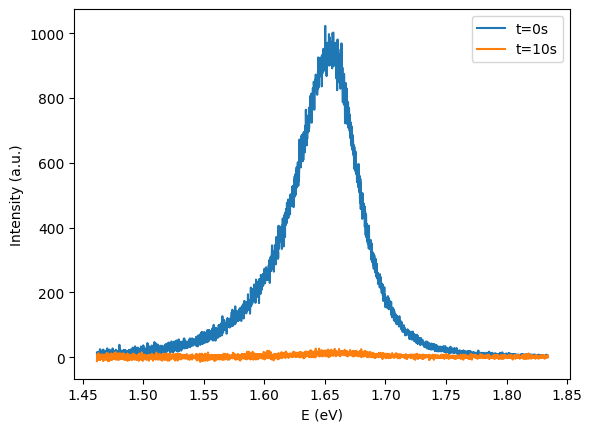

In [7]:
#testowe pojedyncze widma PL, żebym wiedziała co dopasować 
plt.plot(rs_PL_0s[123], I_PL_0s[123],label="t=0s")
plt.plot(rs_PL_10s[123], I_PL_10s[123],label="t=10s")
plt.xlabel(r"E (eV)")
plt.ylabel("Intensity (a.u.)")
plt.legend()

BASE = Path().resolve()
sciezka = BASE / "analiza" / "próbka2" / "wykresy"
plt.savefig(sciezka/'PL.png')

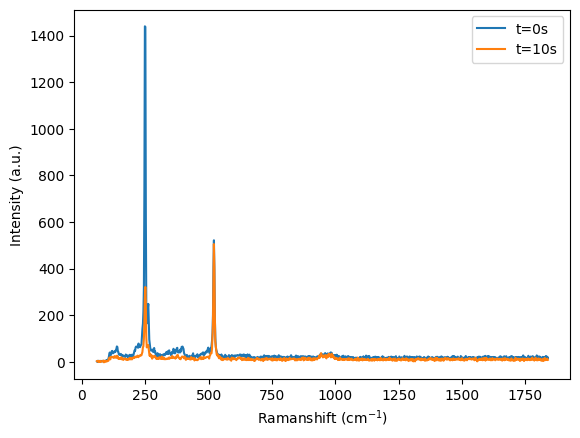

In [8]:
# testowe pojedyncze widma ramana, żebym wiedziała co dopasować 
plt.plot(rs_Raman_0s[123], I_Raman_0s[123],label="t=0s")
plt.plot(rs_Raman_10s[123], I_Raman_10s[123],label="t=10s")
plt.xlabel(r"Ramanshift (cm$^{-1}$)")
plt.ylabel("Intensity (a.u.)")
plt.legend()

plt.savefig(sciezka/'Raman.png')

In [9]:
#dopasowanie PL
centers_PL_0s, fwhms_PL_0s, intensities_PL_0s = lorentz2map(rs_PL_0s, I_PL_0s, xmin=1.5, xmax=1.7)
centers_PL_10s, fwhms_PL_10s, intensities_PL_10s = lorentz2map(rs_PL_10s, I_PL_10s, xmin=1.55, xmax=1.75)



In [10]:
#dopasowanie E
centers_Raman_E_0s, fwhms_Raman_E_0s, intensities_Raman_E_0s = lorentz2map(rs_Raman_0s, I_Raman_0s, xmin=240, xmax=255)
centers_Raman_E_10s, fwhms_Raman_E_10s, intensities_Raman_E_10s = lorentz2map(rs_Raman_10s, I_Raman_10s, xmin=240, xmax=255)



In [11]:
#dopasowanie A
centers_Raman_A_0s, fwhms_Raman_A_0s, intensities_Raman_A_0s = lorentz2map(rs_Raman_0s, I_Raman_0s, xmin=255, xmax=265)
centers_Raman_A_10s, fwhms_Raman_A_10s, intensities_Raman_A_10s = lorentz2map(rs_Raman_10s, I_Raman_10s, xmin=255, xmax=265)


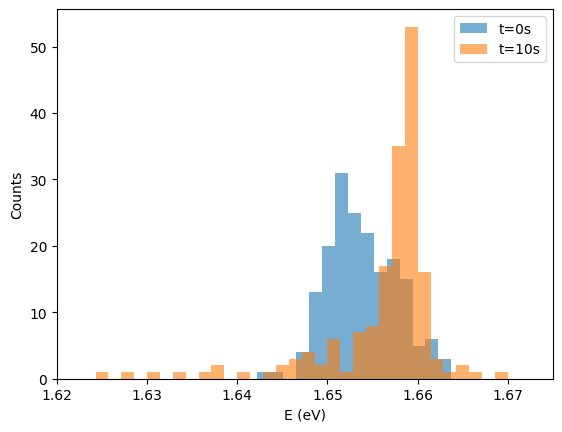

In [37]:
#histogramy pozycji piku PL
plt.hist(centers_PL_0s, bins=15, label="t=0s", alpha=0.6)
plt.hist(centers_PL_10s, bins=140, label="t=10s", alpha=0.6)
plt.xlabel(r"E (eV)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(1.62,1.675)

BASE = Path().resolve()
sciezka = BASE / "analiza" / "próbka2" / "wykresy"
plt.savefig(sciezka/'histogram_pozycji_PL.png')

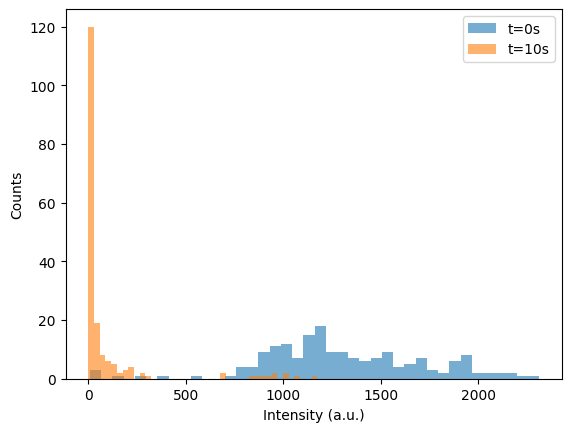

In [38]:
#histogramy intensywności piku PL
plt.hist(intensities_PL_0s, bins=40, label="t=0s", alpha=0.6)
plt.hist(intensities_PL_10s, bins=40, label="t=10s", alpha=0.6)
plt.xlabel(r"Intensity (a.u.)")
plt.ylabel("Counts")
plt.legend()
plt.savefig(sciezka/'histogram_intensywnosci_PL.png')

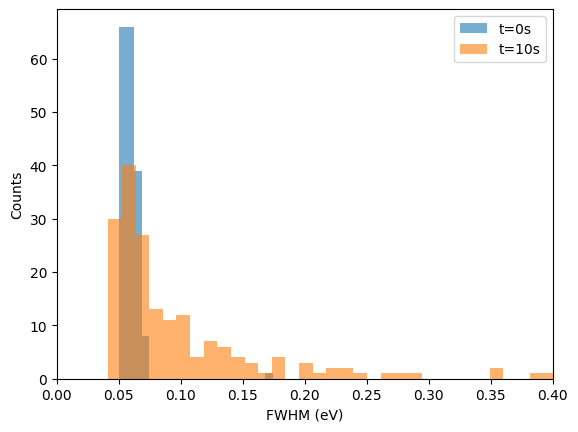

In [39]:
#histogramy fwhm piku PL
plt.hist(fwhms_PL_0s, bins=20, label="t=0s", alpha=0.6)
plt.hist(fwhms_PL_10s, bins=80, label="t=10s", alpha=0.6)
plt.xlabel(r"FWHM (eV)")
plt.ylabel("Counts")
plt.xlim(0,0.4)
plt.legend()
plt.savefig(sciezka/'histogram_fwhm_PL.png')

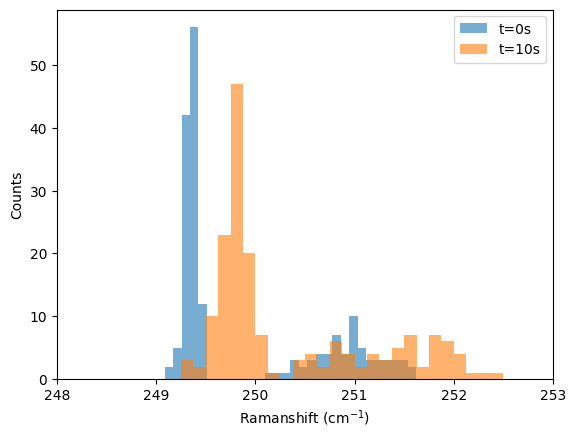

In [40]:
#histogramy pozycji piku Raman E
plt.hist(centers_Raman_E_0s, bins=70, label="t=0s", alpha=0.6)
plt.hist(centers_Raman_E_10s, bins=120, label="t=10s", alpha=0.6)
plt.xlabel(r"Ramanshift (cm$^{-1}$)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(248,253)
plt.savefig(sciezka/'histogram_pozycji_Raman_E.png')

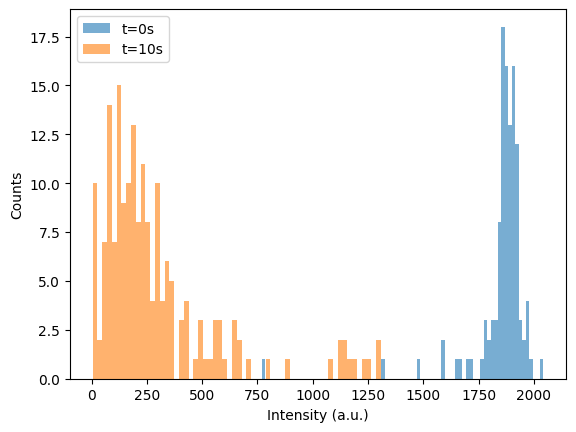

In [47]:
#histogramy intensywności Raman E


maska = (intensities_Raman_E_0s >= 750) & (intensities_Raman_E_0s <= 2400)
intensities_Raman_E_0s = intensities_Raman_E_0s[maska] 


plt.hist(intensities_Raman_E_0s, bins=80, label="t=0s", alpha=0.6)
plt.hist(intensities_Raman_E_10s, bins=60, label="t=10s", alpha=0.6)
plt.xlabel(r"Intensity (a.u.)")
plt.ylabel("Counts")
plt.legend()
plt.savefig(sciezka/'histogram_intensywnosci_Raman_E.png')

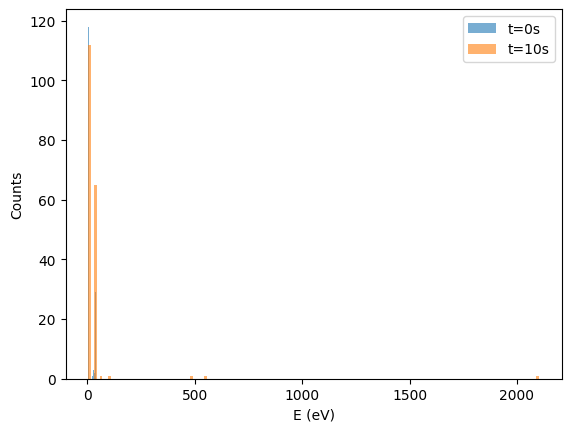

In [51]:
#histogramy fwhm piku Raman E
plt.hist(fwhms_Raman_E_0s, bins=10, label="t=0s", alpha=0.6)
plt.hist(fwhms_Raman_E_10s, bins=160, label="t=10s", alpha=0.6)
plt.xlabel(r"E (eV)")
plt.ylabel("Counts")
plt.legend()
plt.savefig(sciezka/'histogram_fwhm_Raman_E.png')

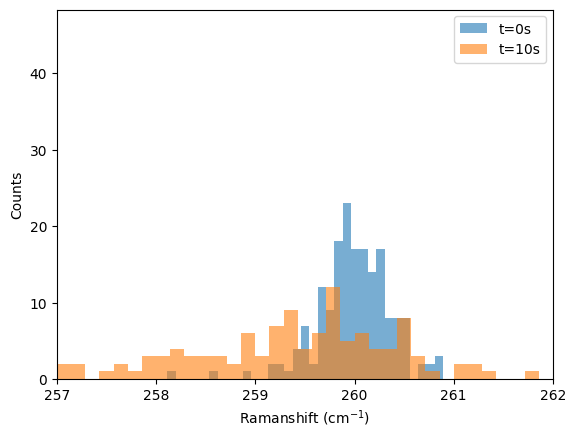

In [52]:
#histogramy pozycji piku Raman A
plt.hist(centers_Raman_A_0s, bins=70, label="t=0s", alpha=0.6)
plt.hist(centers_Raman_A_10s, bins=70, label="t=10s", alpha=0.6)
plt.xlabel(r"Ramanshift (cm$^{-1}$)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(257,262)
plt.savefig(sciezka/'histogram_pozycji_Raman_A.png')

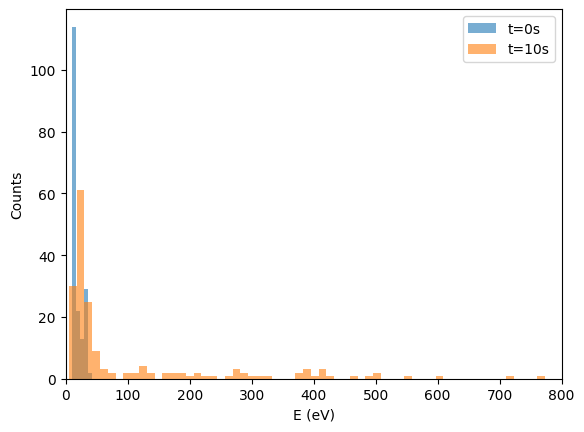

In [64]:
#histogramy fwhm piku Raman A
plt.hist(fwhms_Raman_A_0s, bins=5, label="t=0s", alpha=0.6)
plt.hist(fwhms_Raman_A_10s, bins=430, label="t=10s", alpha=0.6)
plt.xlabel(r"E (eV)")
plt.ylabel("Counts")
plt.legend()
plt.xlim(0,800)
plt.savefig(sciezka/'histogram_fwhm_Raman_A.png')

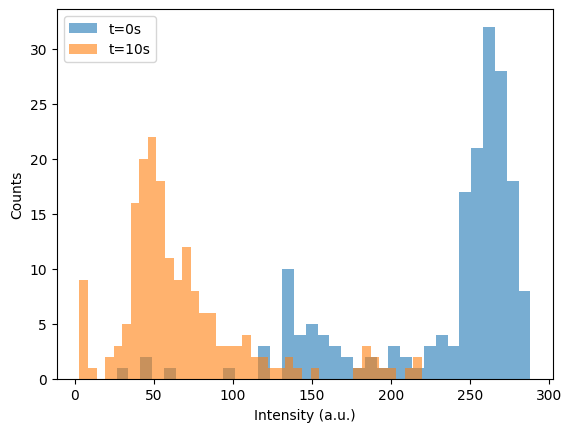

In [67]:
#histogramy intensywności Raman A


plt.hist(intensities_Raman_A_0s, bins=35, label="t=0s", alpha=0.6)
plt.hist(intensities_Raman_A_10s, bins=40, label="t=10s", alpha=0.6)
plt.xlabel(r"Intensity (a.u.)")
plt.ylabel("Counts")
plt.legend()
plt.savefig(sciezka/'histogram_intensywnosci_Raman_A.png')

In [68]:
intensity_PL_mean_1=[np.mean(intensities_PL_0s),np.mean(intensities_PL_10s)]
centers_PL_mean_1=[np.mean(centers_PL_0s),np.mean(centers_PL_10s)]
fwhms_PL_mean_1=[np.mean(fwhms_PL_0s),np.mean(fwhms_PL_10s)]

intensity_Raman_E_mean_1=[np.mean(intensities_Raman_E_0s),np.mean(intensities_Raman_E_10s)]
centers_Raman_E_mean_1=[np.mean(centers_Raman_E_0s),np.mean(centers_Raman_E_10s)]
fwhms_Raman_E_mean_1=[np.mean(fwhms_Raman_E_0s),np.mean(fwhms_Raman_E_10s)]

intensity_Raman_A_mean_1=[np.mean(intensities_Raman_A_0s),np.mean(intensities_Raman_A_10s)]
centers_Raman_A_mean_1=[np.mean(centers_Raman_A_0s),np.mean(centers_Raman_A_10s)]
fwhms_Raman_A_mean_1=[np.mean(fwhms_Raman_A_0s),np.mean(fwhms_Raman_A_10s)]